# New taxonomy features — showcase

The query taxonomy grew four groups. This notebook runs each new bank on
curated inputs so you can see *what it detects* and *how it behaves at the
edges*, then measures the corruption detectors on real cached lane queries.

| Group | Banks (new) | Emits |
|---|---|---|
| Statistical metrics | `RarityBank`, `FragmentationBank` | query-local scalars |
| Corpus-relative | `PMIBank` (+ `CorpusRelativeExtractor`) | scalars vs a collection |
| Corruption | `EncodingArtifactBank`, `TruncationBank`, `PasteResidueBank`, `UnknownTokenRateBank`, `TypoBank` | spans + a rate |
| Semantical | `SegmentationBank` | language-labeled spans (+ derived `language_set`/`is_code_switched`) |

Run top to bottom. Nothing here fetches — the real-data section reads the
local registry cache only.

In [1]:
import pandas as pd

from dataset_registry import DATASETS
from query_taxonomy.corpus_relative import CorpusIndex, CorpusRelativeExtractor, PMIBank
from query_taxonomy.corruption import (
    EncodingArtifactBank, PasteResidueBank, TruncationBank, TypoBank, UnknownTokenRateBank,
)
from query_taxonomy.core import Engine
from query_taxonomy.features import FeatureExtractor
from query_taxonomy.metrics.fragmentation import FragmentationBank
from query_taxonomy.metrics.frequency import RarityBank
from query_taxonomy.taxonomy import FeatureGroup

pd.set_option("display.width", 220, "display.max_columns", None)


def stat_table(bank, texts):
    """One row per text, one column per emitted scalar."""
    rows = [{"query": t, **{s.name: round(s.value, 3) for s in bank.compute(t)}} for t in texts]
    return pd.DataFrame(rows).set_index("query").fillna("—")

/Users/andrei/projects/hybrid-search-rrf-dataset/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1 · Statistical metrics (corpus-free)

### Rarity — `min_zipf`, `mean_zipf`, `rare_share`

Zipf is log-frequency (higher = more common). `min_zipf` is the rarest term —
the sparse exact-match anchor — so a common query with one exotic word reads
differently from a uniformly rare one. `rare_share` is the fraction below the
rarity cutoff. Tokens absent from the table are left to `unknown_token_rate`,
so a query with no known word emits nothing.

In [2]:
stat_table(RarityBank(), [
    "what is the best day to travel",        # common
    "myocardial infarction pathophysiology",  # uniformly rare
    "kubernetes ingress controller latency",  # one rare anchor in tech text
    "aaaa bbbb cccc",                          # synthetic-rare
])

,min_zipf,mean_zipf,rare_share
query,,,
what is the best day to travel,5.00,6.486,0.0
myocardial infarction pathophysiology,2.66,2.810,1.0
kubernetes ingress controller latency,2.25,3.120,0.5
aaaa bbbb cccc,1.30,1.900,1.0


### Subword fragmentation — `mean_pieces_per_word`, `max_pieces_per_word`

How far each word shatters under a pinned WordPiece vocab (1 = clean). `max`
is the single most-shattered token. Grouped by the tokenizer's own word
boundaries, so punctuation and hyphens never inflate a neighbour.

In [3]:
stat_table(FragmentationBank(), [
    "what is the best day",                    # clean -> 1.0
    "phosphorylation dysregulation",           # uniformly shattered
    "antidisestablishmentarianism meaning",    # one very long token -> high max
    "what is machine learning?",               # trailing '?' must NOT inflate
])

,mean_pieces_per_word,max_pieces_per_word
query,,
what is the best day,1.0,1.0
phosphorylation dysregulation,5.0,5.0
antidisestablishmentarianism meaning,4.5,8.0
what is machine learning?,1.0,1.0


## 2 · Corpus-relative (measured against a collection)

### PMI — normalized (`mean_pmi`, `min_pmi`), scale-free

Do the query's terms belong together in this collection? Normalized PMI in
[-1, 1]: +1 always co-occur, 0 independent, -1 never together. `min_pmi` is
the least-collocated pair — the unusual combination. Needs the collection's
pairwise co-occurrence counts, handed in on the `CorpusIndex`.

In [4]:
idx = CorpusIndex(
    document_frequencies={"machine": 500, "learning": 400, "banana": 300, "deep": 350},
    n_docs=10_000,
    avgdl=120.0,
    pair_document_frequencies={
        frozenset(("machine", "learning")): 380,  # strong collocation
        frozenset(("deep", "learning")): 300,
        frozenset(("machine", "banana")): 1,       # essentially never together
    },
)
pmi = PMIBank(idx)
pd.DataFrame(
    {" / ".join(p): {s.name: round(s.value, 3) for s in pmi.compute(p)}
     for p in (["machine", "learning"], ["deep", "learning"], ["machine", "banana"])}
).T

,mean_pmi,min_pmi
machine / learning,0.900,0.900
deep / learning,0.874,0.874
machine / banana,-0.294,-0.294


In [5]:
# scale-free: identical probabilities at very different corpus sizes -> identical NPMI
pd.DataFrame({
    f"N={n:,}": {s.name: round(s.value, 4)
                 for s in PMIBank(
                     CorpusIndex({"a": n // 2, "b": n // 2}, n, 100.0,
                                 {frozenset(("a", "b")): int(n * 0.45)})
                 ).compute(["a", "b"])}
    for n in (1_000, 100_000)
}).T

,mean_pmi,min_pmi
"N=1,000",0.7361,0.7361
"N=100,000",0.7361,0.7361


### `CorpusRelativeExtractor` — the whole group at once

Binds every corpus-relative bank to one collection and runs them over a
tokenized query. (The six d47b scalars + PMI.)

In [6]:
ext = CorpusRelativeExtractor(idx)
{s.name: round(s.value, 3) for s in ext.resolve(["machine", "learning", "banana"])}

{'avg_idf': 0.352,
 'max_idf': 0.38,
 'oov_share': 0.0,
 'collection_size': 4.0,
 'avg_doc_length': 2.083,
 'vocab_overlap': 0.04,
 'mean_pmi': -0.131,
 'min_pmi': -1.0}

## 3 · Corruption

Five detectors. The table shows the **resolved** output of the extractor —
i.e. after within-group claim resolution, which is what a dataset row actually
gets. Note the false-positive rejections (generics, array indices, names) and
the claim priority (a truncated fragment is not also counted as a typo).

In [7]:
fx = FeatureExtractor(engines=(Engine.REGEX, Engine.WORDFREQ))
SPAN_KINDS = ["encoding_artifact", "truncation", "paste_residue", "typo"]


def resolved(texts):
    rows = []
    for t in texts:
        r = fx.resolve(t, groups=[FeatureGroup.CORRUPTION])
        spans = r.spans.get(FeatureGroup.CORRUPTION, {})
        stats = r.stats.get(FeatureGroup.CORRUPTION, {})
        row = {"query": t}
        for kind in SPAN_KINDS:
            row[kind] = ", ".join(s.text for s in spans.get(kind, [])) or "—"
        rate = stats.get("unknown_token_rate")
        row["unk_rate"] = round(rate[0].value, 2) if rate else "—"
        rows.append(row)
    return pd.DataFrame(rows).set_index("query")


resolved([
    "how to confgure ngin...",     # typo + truncation
    "cafÃ© near the office",        # encoding (mojibake)
    "see <div>content</div> here", # real HTML paste
    "List<int> vs List<String>",   # generic type -> NOT paste
    "array[0] index access",       # index -> NOT paste
    "deploy Qdrant to production",  # name -> NOT a typo
    "a normal clean query",        # clean
])

,encoding_artifact,truncation,paste_residue,typo,unk_rate
query,,,,,
how to confgure ngin...,—,ngin...,—,confgure,0.50
cafÃ© near the office,Ã©,—,—,—,0.25
see <div>content</div> here,—,—,"<div>, </div>",—,0.00
List<int> vs List<String>,—,—,—,—,0.00
array[0] index access,—,—,—,—,0.00
deploy Qdrant to production,—,—,—,—,0.25
a normal clean query,—,—,—,—,0.00


**Claim resolution in action.** In `how to confgure ngin...`, truncation
claims `ngin...` (fragment + ellipsis), so the typo bank does not *also* flag
`ngin` — only the interior `confgure`. Standalone, each bank would fire on the
overlap; the extractor's registry resolves it by tier
(RIGID → MODERATE → AMBIGUOUS).

In [8]:
r = fx.resolve("how to confgure ngin...", groups=[FeatureGroup.CORRUPTION])
{k: [s.text for s in v] for k, v in r.spans[FeatureGroup.CORRUPTION].items()}

{'truncation': ['ngin...'], 'typo': ['confgure']}

## 4 · How they perform on real data

Corruption detectors over a sample of real cached queries — on natural text
the hit rate is essentially the detector's **false-positive rate**. This is
the signal the corruption census exists to surface (see
`src/scripts/corruption_census.py` for the full sweep).

In [9]:
by_name = {d.name: d for d in DATASETS}
banks = [EncodingArtifactBank(), TruncationBank(), PasteResidueBank(), TypoBank()]
LANES = ["orcas", "gooaq", "antique", "clerc", "bright-stackoverflow", "miracl-en-dev"]

rows = {}
for lane in LANES:
    sample = by_name[lane].sample_queries(400, seed=0)
    n = len(sample)
    rows[lane] = {
        b.name.value: sum(bool(b.compute(q.text)) for q in sample) / n for b in banks
    }
    rows[lane]["unknown_rate"] = sum(
        s.value for q in sample for s in UnknownTokenRateBank().compute(q.text)
    ) / n
rates = pd.DataFrame(rows).T
rates.round(4)

[orcas] cache hit -> /Users/andrei/projects/hybrid-search-rrf-dataset/src/data/registry_cache/orcas.parquet (10,405,342 queries, no network)
[gooaq] cache hit -> /Users/andrei/projects/hybrid-search-rrf-dataset/src/data/registry_cache/gooaq.parquet (3,031,709 queries, no network)
[antique] cache hit -> /Users/andrei/projects/hybrid-search-rrf-dataset/src/data/registry_cache/antique.parquet (200 queries, no network)
[clerc] cache hit -> /Users/andrei/projects/hybrid-search-rrf-dataset/src/data/registry_cache/clerc.parquet (327,414 queries, no network)
[bright-stackoverflow] cache hit -> /Users/andrei/projects/hybrid-search-rrf-dataset/src/data/registry_cache/bright-stackoverflow.parquet (117 queries, no network)
[miracl-en-dev] cache hit -> /Users/andrei/projects/hybrid-search-rrf-dataset/src/data/registry_cache/miracl-en-dev.parquet (799 queries, no network)


,encoding_artifact,truncation,paste_residue,typo,unknown_rate
orcas,0.0025,0.0,0.0000,0.0500,0.0940
gooaq,0.0000,0.0,0.0000,0.0075,0.0070
antique,0.0000,0.0,0.0000,0.0450,0.0167
clerc,0.0000,0.0,0.0050,0.2000,0.0069
bright-stackoverflow,0.0000,0.0,0.1026,0.2564,0.0567
miracl-en-dev,0.0000,0.0,0.0000,0.0025,0.0082


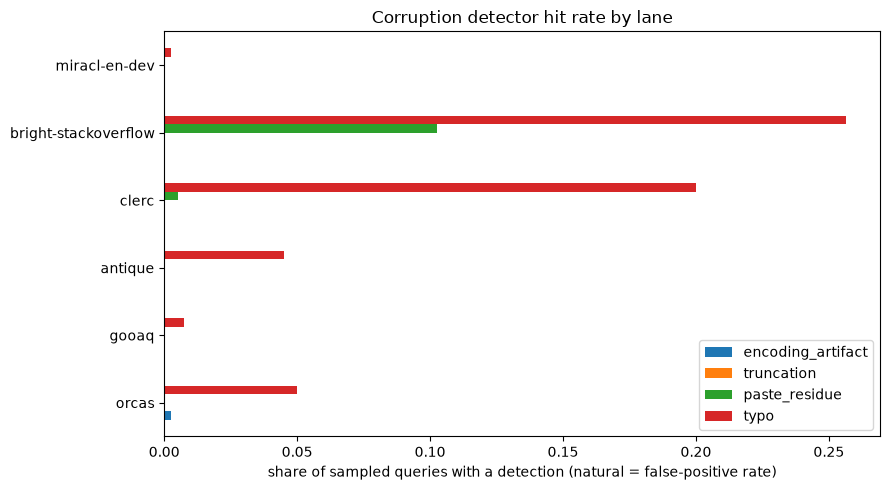

In [10]:
ax = rates[[b.name.value for b in banks]].plot.barh(figsize=(9, 5))
ax.set_xlabel("share of sampled queries with a detection (natural = false-positive rate)")
ax.set_title("Corruption detector hit rate by lane")
ax.figure.tight_layout()

Read `unknown_rate` on `miracl-en-dev` with care: on non-English text it
measures absence-from-English, which is language, not corruption. The other
open calibration knobs (`FREQUENT_ZIPF`, `RARE_ZIPF_MAX`, typo edit-distance,
truncation gating) are the TODOS items the full census informs.

## 5 · Corruption augmentation — producing the supply

Everything above DETECTS corruption. This section produces it, which is the
other half the dataset needs: `encoding_artifact` fires on 0.000 of natural
queries in 41 of 42 lanes, so corrupted supply can only be generated.

The moves are deterministic — stdlib + wordfreq, no model. Same seed, same
damage, so a corrupted row reproduces from its `query_id` alone. Each move
aims at exactly one detector and verifies its own result: the typo move
checks the corrupted token really left the frequency table, which is what
makes `TypoBank` recognise it.

In [14]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)
pd.set_option("display.max_columns", None)

In [19]:
from random import Random
from IPython.display import display

from augmentation.config import AugmentationConfig
from augmentation.corruption import (
    PERTURBATIONS, CorruptionDegree, CorruptOperator, LaneBaseline, QueryCorruptor,
)
from query_taxonomy.taxonomy import CorruptionKind

AUG_QUERY = "how to configure nginx reverse proxy for a docker container"


display(pd.DataFrame([
    {
        "move": type(p).__name__,
        "aims at": p.kind.value,
        "repeatable": p.repeatable,
        "result": p.apply(AUG_QUERY, Random(0)),
    }
    for p in PERTURBATIONS
]).set_index("move"))

,aims at,repeatable,result
move,,,
QwertyTypo,typo,True,how to configure nginx reverse prixy for a docker container
Mojibake,encoding_artifact,False,how to configure nginx revÃ©rse proxy for a docker container
Truncate,truncation,False,how to configure nginx reverse proxy for a docker contain...


### Degree = a delta over the row's OWN span count

`clean` / `light` / `heavy` are +0 / +1 / +3 detector spans on top of
whatever the parent already carries — not a hand-set character rate, which
could not survive a corpus where the natural rate spans two orders of
magnitude (miracl 0.001, bright-robotics 0.465).

The corruptor re-measures after every move and stops on target, so a query
that arrives already damaged gets junked less. `repeatable` is why `heavy`
stays legible: mojibake applied twice nests into `tÃ\x83Â\x83Ã\x82Â³`, so only
the typo move may be spent more than once.

In [20]:
baseline = LaneBaseline(AugmentationConfig().paths.corruption_census)
corruptor = QueryCorruptor(baseline)

pd.DataFrame([
    {"degree": d.value, "spans": corruptor.spans(out), "query": out}
    for d in CorruptionDegree
    for out in [corruptor.corrupt(AUG_QUERY, "miracl-en-dev", d, "q1")]
]).set_index("degree")

,spans,query
degree,,
clean,0,how to configure nginx reverse proxy for a docker container
light,1,how to configure nginx reverse proxy for a docker coÃ±tainer
heavy,3,hoq tÃ³ configure nginx reverse proxy for a docker con...


### Which detector the budget buys — the census decides

Spending is ordered by **lane headroom**: the detector with the lowest
natural rate in that lane goes first, because a lane already firing typo on
47% of its queries learns nothing from one more typo.

Read the result honestly — after the truncation-guard repair,
`encoding_artifact` is the rarest signal on **39 of 42 lanes**, so the order
is near-uniform. `orcas` is the only lane carrying natural mojibake (0.0010)
and so the only one that spends its first span elsewhere. The per-lane
signal is real but thin; it bites hardest on `typo`, which is the one
detector whose natural rate genuinely varies (0.000 → 0.465).

In [21]:
pd.DataFrame([
    {
        "lane": lane,
        "natural typo": round(baseline.rate(lane, CorruptionKind.TYPO), 4),
        "spends in order": " > ".join(k.value for k in baseline.by_headroom(lane)),
        "light": corruptor.corrupt(AUG_QUERY, lane, CorruptionDegree.LIGHT, "q1"),
    }
    for lane in ("miracl-en-dev", "orcas", "bright-robotics", "freshstack-angular")
]).set_index("lane")

,natural typo,spends in order,light
lane,,,
miracl-en-dev,0.0013,encoding_artifact > truncation > typo,how to configure nginx reverse proxy for a docker coÃ±tainer
orcas,0.0405,truncation > encoding_artifact > typo,how to configure nginx reverse proxy for a docker co...
bright-robotics,0.4653,encoding_artifact > truncation > typo,how to configure nginx reverse proxy for a docker coÃ±tainer
freshstack-angular,0.3721,encoding_artifact > truncation > typo,how to configure nginx reverse proxy for a docker coÃ±tainer


### The operator — and why it never calls the model

`CorruptOperator` is a normal augmentation `Operator` (it declares, dispatches
by floor, and states a verifiable postcondition), with one difference: it
implements `apply()`. The loop takes that branch, runs the local re-measure
as the acceptance, and the row costs **zero completions and zero tokens**.

`instruction()` refuses on purpose. A model asked for a QWERTY-adjacent typo
normalises it away, and nothing it returns reproduces from a seed.

In [ ]:
op = CorruptOperator()
parent = pd.Series({"query": AUG_QUERY, "dataset": "miracl-en-dev", "query_id": "q1"})

print("serves corruption:heavy :", op.serves("corruption:heavy"))
print("serves corruption:bogus :", op.serves("corruption:bogus"))
print("answer key              :", op.declaration.answer_key.value)
print("credit gate             :", op.declaration.credit_gate.value)
print("targets                 :", [s.feature for s in op.targets("corruption:heavy", parent).spans])
print("apply()                 :", op.apply(parent, "corruption:heavy"))
try:
    op.instruction("corruption:heavy", parent)
except NotImplementedError as refusal:
    print("instruction()           : refused —", refusal)

**What is still open.** These rows bank as *feature-stock*, not credit —
`credit_gate=declaration_audit`. Heavy damage poisons the spaCy tagger, so a
corrupted row can drift out of the class it was generated for, and that audit
is unrun.

Word-order noise (drop / shuffle) is deliberately absent: it has no detector
by design, so it could never earn a degree's span credit. The remaining
truncation false-positive — a *complete* word before the ellipsis
("well...") — needs a vocabulary gate that would overturn `the answer is…`,
a currently declared positive case.

## 6 · Semantical — language segmentation

One bank, `SegmentationBank` (LANGID engine, `lingua`, SPEC d18 /
`docs/adr/0002-lang-id-library.md`). It partitions a query into contiguous
single-language spans; `language_set`, `language_count`, and
`is_code_switched` are **derived views** on `QueryFeatures`, not separate
banks — `is_code_switched` is mechanical (`language_count >= 2`), not the
"natural, culturally embedded" code-switching the taxonomy originally
described.

The candidate set is English plus non-Latin-script languages only (`ru`,
`zh`, `ar`, `ja`, `ko`, `hi`, `fa`, `th`, `bn`, `te`, `el`, `he`, `uk`).
Latin-script neighbours (`de`, `fr`, `es`, `it`, `nl`, `pt`) are deliberately
excluded — with them in the candidate set, `lingua` sprayed them across
short English and code-heavy queries (9-98% spurious `is_code_switched` on
English lanes). Dropping them means all Latin text resolves to `en`, so a
technical query full of jargon stays monolingual and only a script change
registers as a language switch.

In [4]:
fx_lang = FeatureExtractor(engines=(Engine.LANGID,))

pd.set_option("display.max_colwidth", None)

def language_table(texts):
    rows = []
    for t in texts:
        r = fx_lang.resolve(t, groups=[FeatureGroup.SEMANTICAL])
        spans = r.segments[FeatureGroup.SEMANTICAL]["language_segmentation"]
        rows.append({
            "query": t,
            "segments": ", ".join(f"{s.text!r}/{s.language}" for s in spans),
            "language_set": ",".join(r.language_set),
            "code_switched": r.is_code_switched,
        })
    return pd.DataFrame(rows).set_index("query")


language_table([
    "what is the capital of france",          # clean English -> one en span
    "лучшие рестораны в москве",               # pure Russian -> one ru span, not a switch
    "best restaurants в москве",                # genuine mix -> en + ru, switched
    "kubectl get pods --namespace default",    # Latin/technical jargon -> stays en, NOT switched
    "42.0",                                      # letterless -> en fallback
    "best ramen 東京",                            # lone embedded word -> not segmented, stays en
    """
    Насчет сида что сделано:
    https://docs.google.com/document/d/1kYuyzyJgsOt46owzp31CCvYamiSlhx7QMxdvgOwRb5A/edit?tab=t.eszh51hszyh1#heading=h.397nzg8i62cx

    Multihop & single-hop retrieval. Multihop sid-1 wins by 20% 
    Что хочу сделать:

    Tier1: Add more of the tool configurations (limit N elements instead of top5, select DBSF instead of RRF, select more from the tool than top 50). Finally last cell is where cell by itself tries to select the best config. Думаю класнная вещь потому что разрешает нам посмортеть сколько максимум можно выжать и сида так чтобы она сама себя корректировала не только в query generate но и в config generation
    Tier2: Add more exotic tools to sid (currently only read (hybrid), and readtext (sparse) )  - recommend, precise_search (using colbert multivector) - how well can sid adjust to different tooling scenarios and can it use to its benefit.
    Tier3: Quantization under sid - how does quantization influence search results and will the sid use benefits of its intelligence to make better queries, or get the same results (even if more hops are needed) but on quantized setting. If it can what is the tradeoff (runtime cost vs deployed search backend improvement)
    Как-то так. Нил хотел еще чтобы я посмотрел на фильтеринг - я бы хотел но Musique не подходит для этого таска а переключаться на другой датасет долго и муторно (edited)
    """
])

,segments,language_set,code_switched
query,,,
what is the capital of france,'what is the capital of france'/en,en,False
лучшие рестораны в москве,'лучшие рестораны в москве'/ru,ru,False
best restaurants в москве,"'best restaurants '/en, 'в москве'/ru","en,ru",True
kubectl get pods --namespace default,'kubectl get pods --namespace default'/en,en,False
42.0,'42.0'/en,en,False
best ramen 東京,'best ramen 東京'/en,en,False
"\n Насчет сида что сделано:\n https://docs.google.com/document/d/1kYuyzyJgsOt46owzp31CCvYamiSlhx7QMxdvgOwRb5A/edit?tab=t.eszh51hszyh1#heading=h.397nzg8i62cx\n\n Multihop & single-hop retrieval. Multihop sid-1 wins by 20% \n Что хочу сделать:\n\n Tier1: Add more of the tool configurations (limit N elements instead of top5, select DBSF instead of RRF, select more from the tool than top 50). Finally last cell is where cell by itself tries to select the best config. Думаю класнная вещь потому что разрешает нам посмортеть сколько максимум можно выжать и сида так чтобы она сама себя корректировала не только в query generate но и в config generation\n Tier2: Add more exotic tools to sid (currently only read (hybrid), and readtext (sparse) ) - recommend, precise_search (using colbert multivector) - how well can sid adjust to different tooling scenarios and can it use to its benefit.\n Tier3: Quantization under sid - how does quantization influence search results and will the sid use benefits of its intelligence to make better queries, or get the same results (even if more hops are needed) but on quantized setting. If it can what is the tradeoff (runtime cost vs deployed search backend improvement)\n Как-то так. Нил хотел еще чтобы я посмотрел на фильтеринг - я бы хотел но Musique не подходит для этого таска а переключаться на другой датасет долго и муторно (edited)\n","'\n Насчет сида что сделано:\n '/ru, 'https://docs.google.com/document/d/1kYuyzyJgsOt46owzp31CCvYamiSlhx7QMxdvgOwRb5A/edit?tab=t.eszh51hszyh1#heading=h.397nzg8i62cx\n\n Multihop & single-hop retrieval. Multihop sid-1 wins by 20% \n Что хочу сделать:\n\n Tier1: Add more of the tool configurations (limit N elements instead of top5, select DBSF instead of RRF, select more from the tool than top 50). Finally last cell is where cell by itself tries to select the best config. '/en, 'Думаю класнная '/uk, 'вещь потому что разрешает нам посмортеть сколько максимум можно выжать и сида так чтобы '/ru, 'она сама '/uk, 'себя корректировала не только в '/ru, 'query generate '/en, 'но и в '/ru, 'config generation\n Tier2: Add more exotic tools to sid (currently only read (hybrid), and readtext (sparse) )\xa0 - recommend, precise_search (using colbert multivector) - how well can sid adjust to different tooling scenarios and can it use to its benefit.\n Tier3: Quantization under sid - how does quantization influence search results and will the sid use benefits of its intelligence to make better queries, or get the same results (even if more hops are needed) but on quantized setting. If it can what is the tradeoff (runtime cost vs deployed search backend improvement)\n Как-то так. '/en, 'Нил хотел еще чтобы я посмотрел на фильтеринг - я бы хотел но Musique не подходит для этого таска а переключаться на другой датасет долго и муторно\xa0(edited)\n '/ru","ru,en,uk",True


**Reading the edge cases.** `kubectl get pods --namespace default` is pure
Latin jargon — with the excluded Latin languages back in the candidate set,
this is exactly the kind of query that used to flip `is_code_switched` to
true. `best ramen 東京` keeps `東京` too short a run to earn its own span
("reliable when each language holds a real run"), so the whole query
segments as one `en` span — a real limitation, not a bug to chase.